# 💱 Pure Currency Return Analysis — Indian Investor

**Strategy:** On 1st Jan each year, convert INR → USD → Local Currency. Hold for 1 year. Convert back Local → USD → INR. Measure net return.

**Return Components:**
- `INR/USD move` — did INR depreciate vs USD? (positive = INR weakened = you gain on way back)
- `USD/Local move` — did local currency move vs USD?
- `Net Return` = combined effect of both legs

**Years covered:** 2020, 2021, 2022, 2023, 2024, 2025 (6 full years)

**Plus:** Full period total return (compounded across all years)

---

## 1. 📦 Imports

In [37]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

pio.templates.default = 'plotly_white'

COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONESIA':    '#FF9800',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
    'UK':           '#9C27B0',
}

# All foreign countries (India is home — no conversion needed)
COUNTRIES = ['USA', 'UK', 'TAIWAN', 'INDONESIA', 'CHINA', 'SOUTH AFRICA', 'BRAZIL', 'SOUTH KOREA', 'JAPAN']

COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONESIA':    '#FF9800',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
}

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

print('✅ Setup complete')

✅ Setup complete


## 2. 💾 Download All Currency Data from yFinance

We need **daily data** so we can pick exact 1-Jan and 31-Dec spot rates.

**Tickers:**
- `INR=X` → INR per 1 USD
- `GBPUSD=X` → USD per 1 GBP (we invert to get GBP per USD)
- All others → Local Currency per 1 USD

In [21]:
# Tickers: value = units of LOCAL CURRENCY per 1 USD
# For GBP we invert since yfinance gives USD per GBP
FX_TICKERS = {
    'USA':          None,         # Already USD — only INR/USD leg matters
    'UK':           'GBPUSD=X',   # yfinance: USD per GBP → invert → GBP per USD
    'TAIWAN':       'TWD=X',      # TWD per USD
    'INDONESIA':    'IDR=X',      # IDR per USD
    'CHINA':        'CNY=X',      # CNY per USD
    'SOUTH AFRICA': 'ZAR=X',      # ZAR per USD
    'BRAZIL':       'BRL=X',      # BRL per USD
    'SOUTH KOREA':  'KRW=X',      # KRW per USD
    'JAPAN':        'JPY=X',      # JPY per USD
}

START = '2019-12-28'   # a few days before 2020 to catch 1-Jan rates
END   = '2026-06-05'

# Download INR/USD
print('Downloading INR/USD ...')
inr_raw = yf.download('INR=X', start=START, end=END, interval='1d', auto_adjust=True, progress=False)
inr_series = inr_raw['Close'].squeeze().dropna()
inr_series.index = pd.to_datetime(inr_series.index)
print(f'  INR/USD: {len(inr_series)} daily observations')

# Download each local currency
fx_daily = {}   # country → pd.Series of local_per_USD (daily)
for country, ticker in FX_TICKERS.items():
    if ticker is None:
        fx_daily[country] = None
        continue
    print(f'Downloading {ticker} for {country} ...')
    raw = yf.download(ticker, start=START, end=END, interval='1d', auto_adjust=True, progress=False)
    series = raw['Close'].squeeze().dropna()
    series.index = pd.to_datetime(series.index)
    if ticker == 'GBPUSD=X':
        series = 1.0 / series   # convert to GBP per USD
    fx_daily[country] = series

print('\n✅ All currency data downloaded')

  INR/USD: 1674 daily observations

✅ All currency data downloaded


## 3. 🔧 Helper: Get Spot Rate on a Specific Date

FX markets are closed on weekends and holidays. We use `asof()` to get the **last available rate on or before** the target date.

In [24]:
import pandas as pd

def get_rate(series, date):
    """Get spot rate on or just before a given date."""
    date = pd.Timestamp(date)
    return series.asof(date)


def get_inr_per_local(country, date):
    """
    Returns INR per 1 unit of local currency on a given date.
    
    Formula: INR_per_local = (INR per USD) / (local per USD)
    
    For USA: local = USD, so INR_per_local = INR per USD directly.
    """
    inr_usd = get_rate(inr_series, date)   # INR per 1 USD
    if country == 'USA':
        return inr_usd   # 1 USD = inr_usd INR
    local_usd = get_rate(fx_daily[country], date)   # local per 1 USD
    return inr_usd / local_usd   # INR per 1 local unit


# Original Sanity check (2024)
print('Sanity check — rates on 2024-01-01:')
print(f'  INR/USD : {get_rate(inr_series, "2024-01-01"):.4f}')
print(f'  JPY/USD : {get_rate(fx_daily["JAPAN"], "2024-01-01"):.4f}')
print(f'  INR/JPY : {get_inr_per_local("JAPAN", "2024-01-01"):.6f}')

print('-' * 40)

# New Sanity check — testing the first 6 months of 2026 extension
print('Sanity check — rates on 2026-06-15:')
try:
    print(f'  INR/USD : {get_rate(inr_series, "2026-06-15"):.4f}')
    print(f'  JPY/USD : {get_rate(fx_daily["JAPAN"], "2026-06-15"):.4f}')
    print(f'  INR/JPY : {get_inr_per_local("JAPAN", "2026-06-15"):.6f}')
except Exception as e:
    print(f"Error checking 2026 data: {e}")
    print("Note: Make sure your 'inr_series' and 'fx_daily' DataFrames have been populated with 2026 data.")

Sanity check — rates on 2024-01-01:
  INR/USD : 83.2486
  JPY/USD : 140.9520
  INR/JPY : 0.590617
----------------------------------------
Sanity check — rates on 2026-06-15:
  INR/USD : 96.1645
  JPY/USD : 159.9400
  INR/JPY : 0.601254


## 4. 📊 Yearly Return Calculation

**Exact logic for each year Y and each country:**

```
Buy  date : 1-Jan-Y        (start of year)
Sell date : 1-Jan-(Y+1)    (start of next year = end of holding)

INR invested   = 100 (base)
USD bought     = 100 / INR_per_USD(buy)
Local bought   = USD / local_per_USD(buy)

After 1 year:
USD received   = Local * local_per_USD(sell)    [sell local → USD]
INR received   = USD  * INR_per_USD(sell)        [sell USD → INR]

Net Return %   = (INR_received / 100 - 1) * 100

Also decompose:
  USDINR leg   = (INR_per_USD_sell / INR_per_USD_buy  - 1) * 100
  Local/USD leg= (local_per_USD_buy / local_per_USD_sell - 1) * 100
                  [note: inverted because stronger local = lower local/USD]
```

In [31]:
results = []   # one row per (country, period)

# FORCE 2026 into the loop execution
EXECUTION_YEARS = [y for y in YEARS if y != 2026] + [2026] if 'YEARS' in locals() else [2024, 2025, 2026]

for country in COUNTRIES:
    for year in EXECUTION_YEARS:
        # Determine dates based on whether we are calculating the 2026 extension
        if year == 2026:
            buy_date  = '2026-01-01'
            sell_date = '2026-07-01'  # Captures the first 6 months of 2026
            period_label = '2026 (H1)'
        else:
            buy_date  = f'{year}-01-01'
            sell_date = f'{year+1}-01-01'
            period_label = str(year)

        # Fetch rates
        inr_buy  = get_rate(inr_series, buy_date)    # INR per USD at start
        inr_sell = get_rate(inr_series, sell_date)   # INR per USD at end

        # INR/USD leg return
        usdinr_return = (inr_sell / inr_buy - 1) * 100

        if country == 'USA':
            local_usd_return = 0.0
            net_return       = usdinr_return
            inr_received     = 100 * (1 + net_return / 100)

        else:
            local_buy  = get_rate(fx_daily[country], buy_date)    # local per USD at start
            local_sell = get_rate(fx_daily[country], sell_date)   # local per USD at end

            # Local vs USD leg
            local_usd_return = (local_buy / local_sell - 1) * 100

            # Full round-trip
            usd_bought   = 100 / inr_buy          
            local_bought = usd_bought * local_buy  
            usd_back     = local_bought / local_sell
            inr_received = usd_back * inr_sell
            net_return   = (inr_received / 100 - 1) * 100

        results.append({
            'Country':              country,
            'Period':               period_label,  
            'INR/USD Buy':          round(inr_buy,  4),
            'INR/USD Sell':         round(inr_sell, 4),
            'USDINR Return (%)':    round(usdinr_return,    2),
            'Local/USD Return (%)': round(local_usd_return, 2),
            'Net Return (%)':       round(net_return,       2),
            'INR Received (per 100)': round(inr_received,   2)
        })

results_df = pd.DataFrame(results)
print(f'✅ Calculated {len(results_df)} country-period combinations')

✅ Calculated 63 country-period combinations


In [32]:
print("--- Data Availability Check ---")
try:
    print(f"INR/USD Jan 1: {inr_series.asof(pd.Timestamp('2026-01-01'))}")
    print(f"INR/USD Jul 1: {inr_series.asof(pd.Timestamp('2026-07-01'))}")
    print("✅ 2026 Data is present in your series.")
except Exception as e:
    print(f"❌ Error fetching 2026 dates: {e}")
    print("Your underlying dataframes (inr_series/fx_daily) might not have 2026 data loaded yet.")

--- Data Availability Check ---
INR/USD Jan 1: 89.76940155029297
INR/USD Jul 1: 96.16449737548828
✅ 2026 Data is present in your series.


## 5. 📋 The Main 6×9 Table — Yearly Net Currency Return

In [33]:
# Pivot: rows = Country, columns = Period, values = Net Return
net_pivot = results_df.pivot(index='Country', columns='Period', values='Net Return (%)')
net_pivot.columns.name = None

print('📋 NET CURRENCY RETURN (%) — Indian Investor (INR → USD → Local → USD → INR)')
print('Positive = you gained | Negative = you lost after full round-trip')
print()

# Render table with conditional color formatting
net_pivot.style \
    .format('{:.2f}%') \
    .background_gradient(cmap='RdYlGn', axis=None) \
    .set_caption('Net Currency Return (%) per Period — Indian Investor')

📋 NET CURRENCY RETURN (%) — Indian Investor (INR → USD → Local → USD → INR)
Positive = you gained | Negative = you lost after full round-trip



,2020,2021,2022,2023,2024,2025,2026 (H1)
Country,,,,,,,
BRAZIL,-20.67%,-5.08%,17.31%,9.49%,-19.09%,18.05%,15.54%
CHINA,9.30%,4.39%,1.84%,-1.00%,-0.19%,9.16%,10.71%
INDONESIA,0.76%,-0.68%,1.78%,2.05%,-1.45%,0.74%,-0.58%
JAPAN,7.96%,-8.64%,-3.66%,-5.23%,-7.48%,5.03%,4.76%
SOUTH AFRICA,-0.89%,-7.19%,4.51%,-6.92%,0.33%,18.39%,8.74%
SOUTH KOREA,9.08%,-7.17%,5.08%,-2.09%,-9.16%,6.79%,0.67%
TAIWAN,9.19%,3.38%,0.33%,0.49%,-3.49%,9.72%,6.23%
UK,5.72%,0.54%,-0.60%,6.11%,1.58%,12.30%,6.81%
USA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%,7.12%


In [36]:
# Local vs USD leg
local_pivot = results_df.pivot(index='Country', columns='Period', values='Local/USD Return (%)')
local_pivot.columns.name = None

print('📋 LOCAL CURRENCY vs USD LEG (%) — Country-Specific Move')
print('Positive = local currency strengthened vs USD = gain for Indian investor')
local_pivot.style \
    .format('{:.2f}%') \
    .background_gradient(cmap='RdYlGn', axis=None)

📋 LOCAL CURRENCY vs USD LEG (%) — Country-Specific Move
Positive = local currency strengthened vs USD = gain for Indian investor


,2020,2021,2022,2023,2024,2025,2026 (H1)
Country,,,,,,,
BRAZIL,-22.64%,-6.79%,5.40%,8.95%,-21.49%,12.81%,7.85%
CHINA,6.59%,2.50%,-8.49%,-1.49%,-3.14%,4.32%,3.35%
INDONESIA,-1.74%,-2.47%,-8.55%,1.54%,-4.37%,-3.73%,-7.19%
JAPAN,5.28%,-10.29%,-13.43%,-5.70%,-10.22%,0.37%,-2.21%
SOUTH AFRICA,-3.35%,-8.86%,-6.10%,-7.38%,-2.64%,13.14%,1.51%
SOUTH KOREA,6.37%,-8.84%,-5.58%,-2.57%,-11.85%,2.05%,-6.03%
TAIWAN,6.48%,1.52%,-9.85%,-0.01%,-6.34%,4.85%,-0.83%
UK,3.09%,-1.28%,-10.68%,5.59%,-1.42%,7.32%,-0.30%
USA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## 6. 🌍 Full Period Total Return (Compounded)

In [38]:
# Compound all returns for each country including H1 2026
total_rows = []

# Define a quick sorting map to ensure '2026 (H1)' comes chronologically after the years
def get_period_order(period_str):
    if 'H1' in period_str:
        return float(period_str.split()[0]) + 0.5
    return float(period_str)

for country in COUNTRIES:
    # Filter for the country and sort chronologically using our helper map
    df_c = results_df[results_df['Country'] == country].copy()
    df_c['sort_key'] = df_c['Period'].apply(get_period_order)
    df_c = df_c.sort_values('sort_key').drop(columns=['sort_key'])

    # Compounded growth: start with 100 INR, apply each period's return
    inr_value = 100.0
    n_years = 0.0  # Track total fractional years elapsed
    
    for _, row in df_c.iterrows():
        inr_value = inr_value * (1 + row['Net Return (%)'] / 100)
        
        # Increment years dynamically: H1 block is 0.5 years, others are 1.0 year
        if 'H1' in str(row['Period']):
            n_years += 0.5
        else:
            n_years += 1.0

    total_return  = inr_value - 100
    
    # CAGR calculated using exact fractional years elapsed
    cagr          = ((inr_value / 100) ** (1 / n_years) - 1) * 100

    # Also compound USDINR and local legs separately
    usdinr_compound = 100.0
    local_compound  = 100.0
    for _, row in df_c.iterrows():
        usdinr_compound *= (1 + row['USDINR Return (%)'] / 100)
        local_compound  *= (1 + row['Local/USD Return (%)'] / 100)

    total_rows.append({
        'Country':                      country,
        'INR Start':                    100,
        'INR End (compounded)':        round(inr_value, 2),
        'Total Net Return (%)':        round(total_return, 2),
        'CAGR (%)':                    round(cagr, 2),
        'USDINR Total Contribution':  round(usdinr_compound - 100, 2),
        'Local/USD Total Contribution': round(local_compound - 100, 2),
        'Total Years':                  n_years
    })

total_df = pd.DataFrame(total_rows).sort_values('Total Net Return (%)', ascending=False).reset_index(drop=True)
total_df.index += 1

print(f'📋 FULL PERIOD TOTAL RETURN — Compounded across all periods ({int(n_years)} Years + 6 Months)')
print('INR 100 invested on 1-Jan-2020, reinvested sequentially, redeemed 1-Jul-2026')

total_df.style \
    .format({
        'INR End (compounded)':         '{:.2f}',
        'Total Net Return (%)':         '{:.2f}%',
        'CAGR (%)':                     '{:.2f}%',
        'USDINR Total Contribution':    '{:.2f}%',
        'Local/USD Total Contribution': '{:.2f}%',
        'Total Years':                  '{:.1f}'
    }) \
    .background_gradient(subset=['Total Net Return (%)', 'CAGR (%)'], cmap='RdYlGn')

📋 FULL PERIOD TOTAL RETURN — Compounded across all periods (6 Years + 6 Months)
INR 100 invested on 1-Jan-2020, reinvested sequentially, redeemed 1-Jul-2026


,Country,INR Start,INR End (compounded),Total Net Return (%),CAGR (%),USDINR Total Contribution,Local/USD Total Contribution,Total Years
1,CHINA,100,138.76,38.76%,5.17%,34.91%,2.85%,6.5
2,UK,100,136.60,36.60%,4.91%,34.91%,1.24%,6.5
3,USA,100,134.91,34.91%,4.71%,34.91%,0.00%,6.5
4,TAIWAN,100,128.02,28.02%,3.87%,34.91%,-5.10%,6.5
5,SOUTH AFRICA,100,115.57,15.57%,2.25%,34.91%,-14.34%,6.5
6,BRAZIL,100,106.73,6.73%,1.01%,34.91%,-20.91%,6.5
7,INDONESIA,100,102.60,2.60%,0.40%,34.91%,-23.96%,6.5
8,SOUTH KOREA,100,101.74,1.74%,0.27%,34.91%,-24.59%,6.5
9,JAPAN,100,91.67,-8.33%,-1.33%,34.91%,-32.06%,6.5


## 7. 📊 Graphs

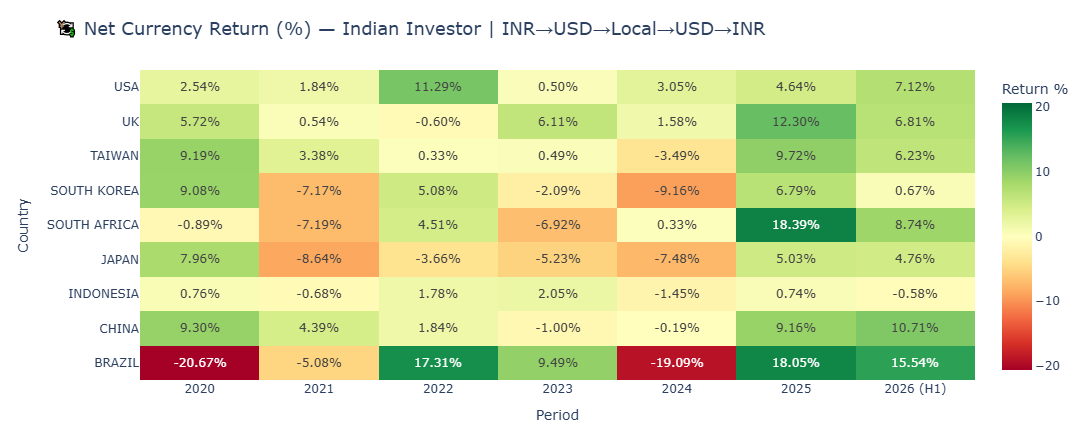

In [39]:
import plotly.graph_objects as go

# ── Graph 1: Heatmap — Net Currency Return by Country × Period ──
fig = go.Figure(data=go.Heatmap(
    z=net_pivot.values,
    x=[str(c) for c in net_pivot.columns],  # This will beautifully map ['2024', '2025', '2026 (H1)']
    y=net_pivot.index.tolist(),
    colorscale='RdYlGn',
    zmid=0,
    text=[[f'{v:.2f}%' if not pd.isna(v) else '' for v in row] for row in net_pivot.values],
    texttemplate='%{text}',
    textfont={'size': 12},
    showscale=True,
    colorbar=dict(title='Return %')
))

fig.update_layout(
    title=dict(text='💱 Net Currency Return (%) — Indian Investor | INR→USD→Local→USD→INR', font=dict(size=18)),
    xaxis_title='Period',  # Updated from 'Year' to 'Period'
    yaxis_title='Country',
    height=440,
    margin=dict(l=140, r=40, t=70, b=60)
)
fig.show()

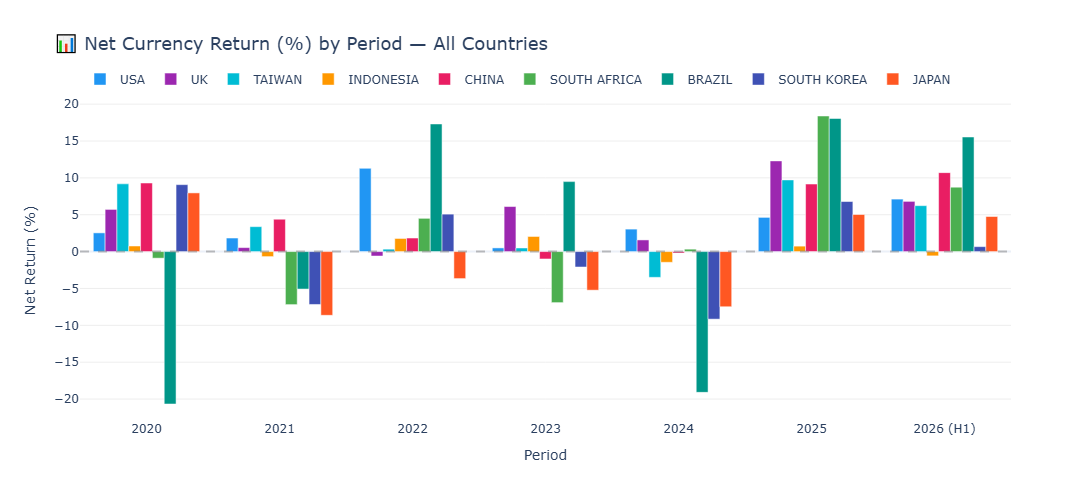

In [40]:
import plotly.graph_objects as go

# ── Graph 2: Grouped Bar — Net Return per Period, grouped by Country ──
fig = go.Figure()

# Reuse our custom period sorting logic to map the chronological order of bars
def get_period_order(period_str):
    if 'H1' in period_str:
        return float(period_str.split()[0]) + 0.5
    return float(period_str)

for country in COUNTRIES:
    df_c = results_df[results_df['Country'] == country].copy()
    
    # Sort chronologically so 2026 (H1) aligns perfectly at the end of the X-axis
    df_c['sort_key'] = df_c['Period'].apply(get_period_order)
    df_c = df_c.sort_values('sort_key')
    
    fig.add_trace(go.Bar(
        name=country,
        x=[str(p) for p in df_c['Period']],  # Maps ['2024', '2025', '2026 (H1)']
        y=df_c['Net Return (%)'],
        marker_color=COUNTRY_COLORS[country]
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)

fig.update_layout(
    title=dict(text='📊 Net Currency Return (%) by Period — All Countries', font=dict(size=18)),
    barmode='group',
    xaxis_title='Period',  # Updated from 'Year'
    yaxis_title='Net Return (%)',
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

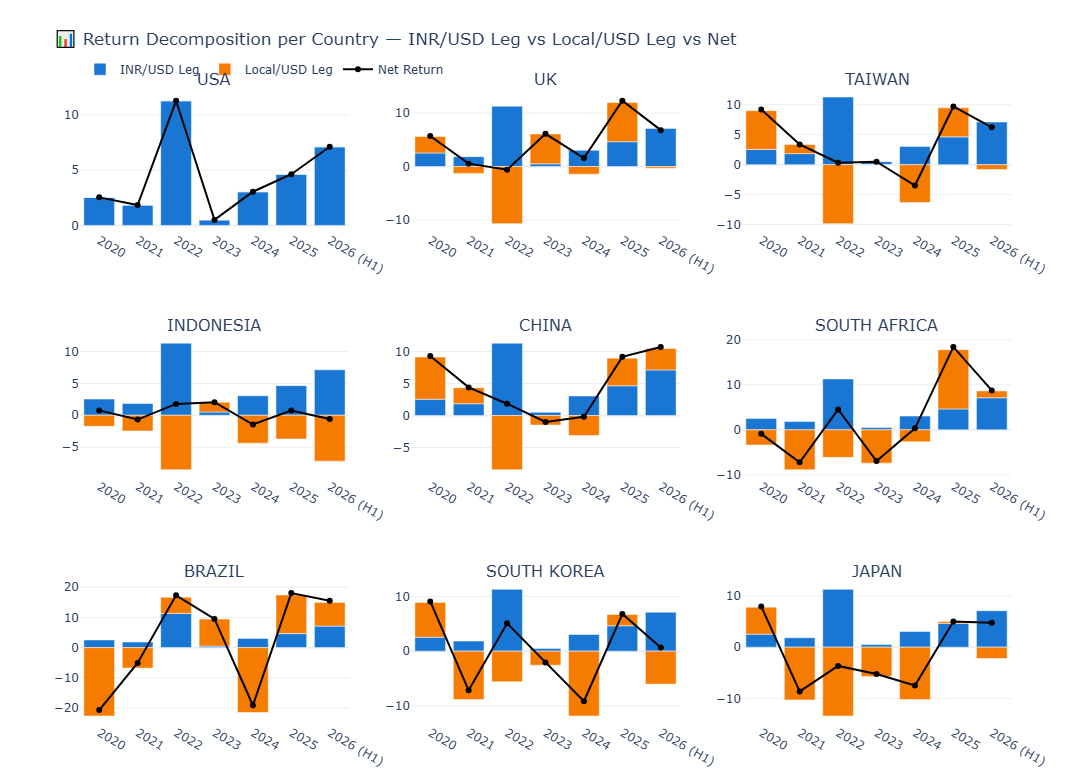

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Graph 3: Stacked Bar — USDINR leg vs Local/USD leg (for each country per period) ──
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

# Helper for chronological period ordering
def get_period_order(period_str):
    if 'H1' in period_str:
        return float(period_str.split()[0]) + 0.5
    return float(period_str)

for idx, country in enumerate(COUNTRIES):
    row = idx // 3 + 1
    col = idx % 3 + 1
    
    df_c = results_df[results_df['Country'] == country].copy()
    
    # Sort chronologically so 2026 (H1) lands perfectly at the right edge of each subplot
    df_c['sort_key'] = df_c['Period'].apply(get_period_order)
    df_c = df_c.sort_values('sort_key')
    
    periods_str = [str(p) for p in df_c['Period']]

    # 1. USDINR return leg
    fig.add_trace(go.Bar(
        x=periods_str,
        y=df_c['USDINR Return (%)'],
        name='INR/USD Leg',
        marker_color='#1976D2',
        showlegend=(idx == 0)
    ), row=row, col=col)

    # 2. Local/USD return leg
    fig.add_trace(go.Bar(
        x=periods_str,
        y=df_c['Local/USD Return (%)'],
        name='Local/USD Leg',
        marker_color='#F57C00',
        showlegend=(idx == 0)
    ), row=row, col=col)

    # 3. Net return as a line
    fig.add_trace(go.Scatter(
        x=periods_str,
        y=df_c['Net Return (%)'],
        name='Net Return',
        line=dict(color='black', width=2),
        mode='lines+markers',
        showlegend=(idx == 0)
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='📊 Return Decomposition per Country — INR/USD Leg vs Local/USD Leg vs Net', font=dict(size=17)),
    barmode='relative',
    height=780,
    plot_bgcolor='rgba(0,0,0,0)',
    legend=dict(orientation='h', yanchor='bottom', y=1.01),
    margin=dict(t=90, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

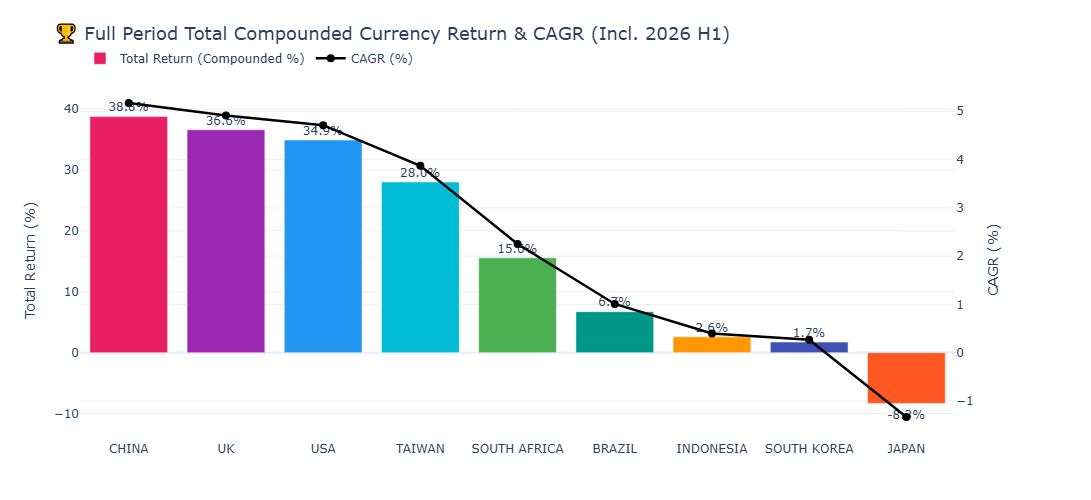

In [42]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Graph 4: Total Return bar + CAGR line ──
total_sorted = total_df.sort_values('Total Net Return (%)', ascending=False)

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Bar(
    x=total_sorted['Country'],
    y=total_sorted['Total Net Return (%)'],
    name='Total Return (Compounded %)',  # Cleaned up '6Y' string
    marker_color=[COUNTRY_COLORS[c] for c in total_sorted['Country']],
    text=[f'{v:.1f}%' for v in total_sorted['Total Net Return (%)']],
    textposition='outside'
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=total_sorted['Country'],
    y=total_sorted['CAGR (%)'],
    name='CAGR (%)',
    line=dict(color='black', width=2.5),
    mode='lines+markers',
    marker=dict(size=8)
), secondary_y=True)

fig.update_layout(
    title=dict(text='🏆 Full Period Total Compounded Currency Return & CAGR (Incl. 2026 H1)', font=dict(size=18)),
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', title='Total Return (%)'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    margin=dict(t=80, b=60)
)
fig.update_yaxes(title_text='CAGR (%)', secondary_y=True)
fig.show()

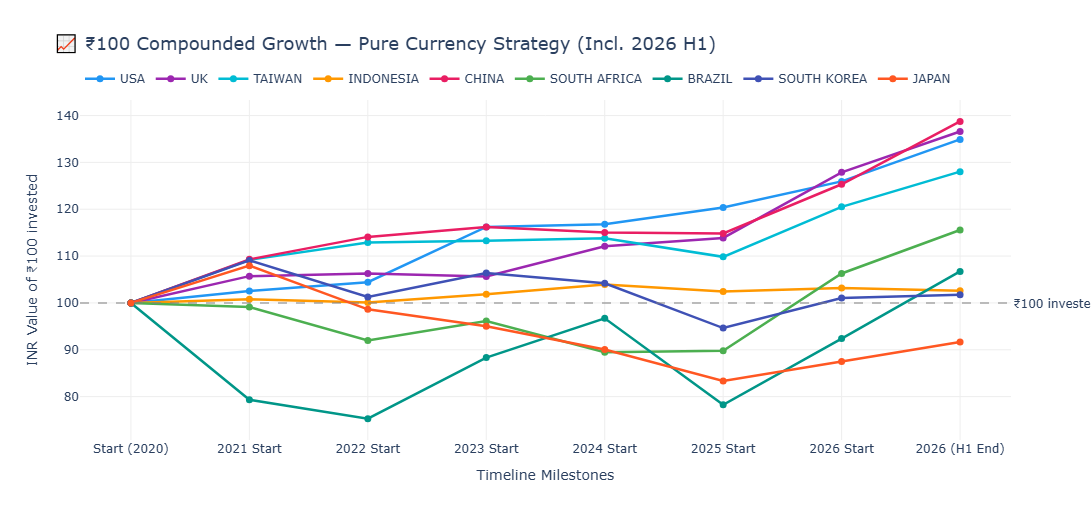

In [43]:
import plotly.graph_objects as go

# ── Graph 5: Compounded INR Growth of ₹100 invested on 1-Jan-2020 ──
fig = go.Figure()

# Helper for chronological period ordering
def get_period_order(period_str):
    if 'H1' in period_str:
        return float(period_str.split()[0]) + 0.5
    return float(period_str)

for country in COUNTRIES:
    df_c = results_df[results_df['Country'] == country].copy()
    
    # Sort chronologically
    df_c['sort_key'] = df_c['Period'].apply(get_period_order)
    df_c = df_c.sort_values('sort_key')
    
    # Growth curve values: starts at base ₹100
    inr_val = [100.0]
    
    # Determine the start label based on the first period
    first_p = df_c['Period'].iloc[0]
    period_labels = [f"Start ({first_p})"]

    for _, row in df_c.iterrows():
        # Compound the cash value forward
        inr_val.append(inr_val[-1] * (1 + row['Net Return (%)'] / 100))
        
        # Dynamically append the label for the end of the current period
        if 'H1' in str(row['Period']):
            period_labels.append("2026 (H1 End)")
        else:
            # e.g., if period is '2024', the end of it is Jan 2025
            next_year = int(row['Period']) + 1
            period_labels.append(f"{next_year} Start")

    fig.add_trace(go.Scatter(
        x=period_labels,
        y=inr_val,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2.5),
        mode='lines+markers',
        marker=dict(size=7)
    ))

fig.add_hline(y=100, line_dash='dash', line_color='gray', opacity=0.5,
              annotation_text='₹100 invested', annotation_position='right')

fig.update_layout(
    title=dict(text='📈 ₹100 Compounded Growth — Pure Currency Strategy (Incl. 2026 H1)', font=dict(size=18)),
    xaxis_title='Timeline Milestones',
    yaxis_title='INR Value of ₹100 invested',
    height=520,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

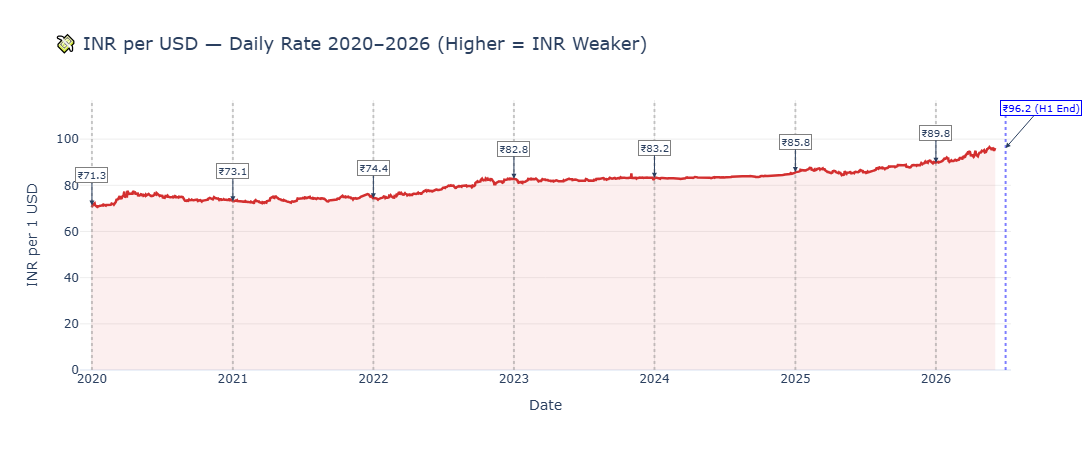

In [44]:
import plotly.graph_objects as go

# ── Graph 6: INR/USD rate over the full period (to see depreciation trend) ──
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=inr_series.index,
    y=inr_series.values,
    line=dict(color='#D32F2F', width=2.5),
    fill='tozeroy',
    fillcolor='rgba(211,47,47,0.08)',
    name='INR per USD'
))

# Dynamically clean milestone years to avoid duplication
milestone_years = list(set([y for y in YEARS if y <= 2026])) + [2026]
milestone_years.sort()

# Mark each 1-Jan milestone
for year in milestone_years:
    milestone_date = f'{year}-01-01'
    try:
        rate = get_rate(inr_series, milestone_date)
        fig.add_vline(x=milestone_date, line_dash='dot', line_color='gray', opacity=0.4)
        fig.add_annotation(x=milestone_date, y=rate, text=f'₹{rate:.1f}',
                           showarrow=True, arrowhead=2, ax=0, ay=-30,
                           font=dict(size=10), bgcolor='white', bordercolor='gray')
    except Exception:
        pass # Skip safely if a historic boundary year falls outside the series frame

# NEW: Mark the end of the first 6 months of 2026 (1-Jul-2026)
try:
    h1_end_date = '2026-07-01'
    h1_rate = get_rate(inr_series, h1_end_date)
    fig.add_vline(x=h1_end_date, line_dash='dot', line_color='blue', opacity=0.5)
    fig.add_annotation(x=h1_end_date, y=h1_rate, text=f'₹{h1_rate:.1f}\n(H1 End)',
                       showarrow=True, arrowhead=2, ax=35, ay=-40,
                       font=dict(size=10, color='blue'), bgcolor='white', bordercolor='blue')
except Exception:
    pass

fig.update_layout(
    title=dict(text='💸 INR per USD — Daily Rate 2020–2026 (Higher = INR Weaker)', font=dict(size=18)),
    xaxis_title='Date',
    yaxis_title='INR per 1 USD',
    height=450,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee', range=['2019-12-01', '2026-07-15'])  # Slightly extended range to frame the final label
)
fig.show()

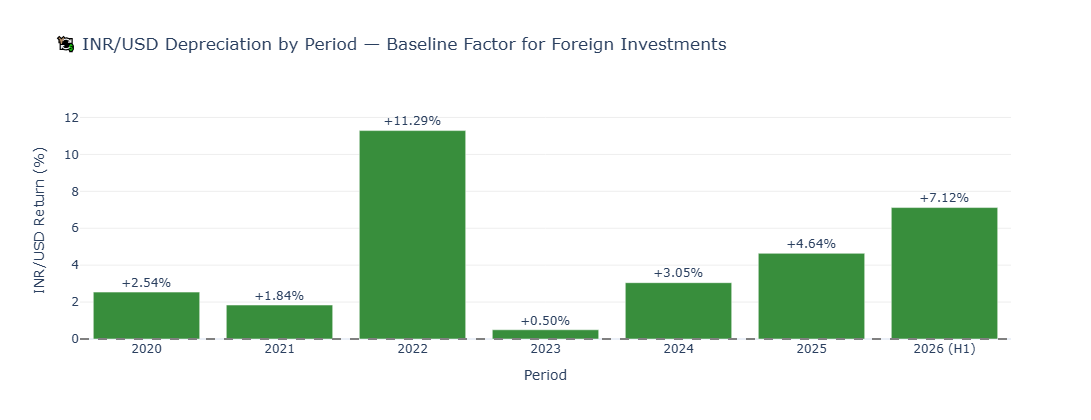

In [45]:
import plotly.graph_objects as go

# ── Graph 7: USDINR period contribution (same for all countries — show once cleanly) ──
# Filter using 'USA' as it cleanly captures the underlying baseline USDINR movement
usdinr_period = results_df[results_df['Country'] == 'USA'].copy()

# Helper for chronological period ordering
def get_period_order(period_str):
    if 'H1' in period_str:
        return float(period_str.split()[0]) + 0.5
    return float(period_str)

# Sort chronologically so 2026 (H1) sits perfectly at the end of the X-axis
usdinr_period['sort_key'] = usdinr_period['Period'].apply(get_period_order)
usdinr_period = usdinr_period.sort_values('sort_key')

# Green for depreciation (positive return for Indian investor), Red for appreciation
bar_colors = ['#388e3c' if v > 0 else '#d32f2f' for v in usdinr_period['USDINR Return (%)']]

fig = go.Figure(go.Bar(
    x=[str(p) for p in usdinr_period['Period']],
    y=usdinr_period['USDINR Return (%)'],
    marker_color=bar_colors,
    text=[f'{v:+.2f}%' for v in usdinr_period['USDINR Return (%)']],
    textposition='outside'
))

fig.add_hline(y=0, line_dash='dash', line_color='gray')

fig.update_layout(
    title=dict(text='💱 INR/USD Depreciation by Period — Baseline Factor for Foreign Investments', font=dict(size=17)),
    xaxis_title='Period',  # Updated from 'Year'
    yaxis_title='INR/USD Return (%)',
    height=420,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False
)
fig.show()

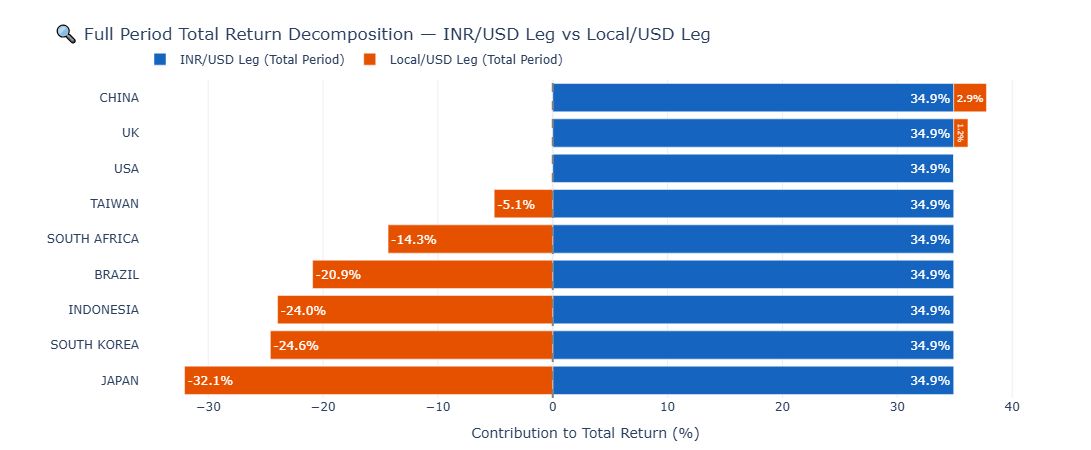

In [46]:
import plotly.graph_objects as go

# ── Graph 8: Contribution breakdown for total period — stacked horizontal bar ──
total_sorted2 = total_df.sort_values('Total Net Return (%)')

fig = go.Figure()
fig.add_trace(go.Bar(
    y=total_sorted2['Country'],
    x=total_sorted2['USDINR Total Contribution'],
    name='INR/USD Leg (Total Period)',  # Updated label name from '6Y'
    orientation='h',
    marker_color='#1565C0',
    text=[f'{v:.1f}%' for v in total_sorted2['USDINR Total Contribution']],
    textposition='inside'
))
fig.add_trace(go.Bar(
    y=total_sorted2['Country'],
    x=total_sorted2['Local/USD Total Contribution'],
    name='Local/USD Leg (Total Period)',  # Updated label name from '6Y'
    orientation='h',
    marker_color='#E65100',
    text=[f'{v:.1f}%' for v in total_sorted2['Local/USD Total Contribution']],
    textposition='inside'
))

fig.update_layout(
    title=dict(text='🔍 Full Period Total Return Decomposition — INR/USD Leg vs Local/USD Leg', font=dict(size=17)),  # Updated title text
    barmode='relative',
    xaxis_title='Contribution to Total Return (%)',
    height=450,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    margin=dict(l=140, r=60, t=80, b=50)
)
fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.show()

## 8. 📝 Final Summary Table — Everything in One Place

In [48]:
print('=' * 80)
print('  PURE CURRENCY RETURN ANALYSIS — INDIAN INVESTOR — COMPLETE SUMMARY')
print('  Strategy: INR → USD → Local Currency, hold 1 year (H1 2026: 6 months), reverse')
print('=' * 80)

print('\n📋 PERIODIC NET RETURN TABLE (rows = country, cols = period):')
print(net_pivot.to_string(float_format=lambda x: f'{x:+.2f}%'))

print('\n\n📋 FULL PERIOD SUMMARY:')
print(total_df[['Country','Total Net Return (%)','CAGR (%)','USDINR Total Contribution','Local/USD Total Contribution', 'Total Years']]
      .to_string(index=False, float_format=lambda x: f'{x:+.2f}%' if isinstance(x, float) else f'{x}'))

print('\n\n🏆 BEST CURRENCY to hold (highest total return):', total_df.iloc[0]['Country'])
print('⚠️  WORST CURRENCY to hold (lowest total return): ', total_df.iloc[-1]['Country'])

# INR total depreciation vs USD over full period window (Jan 2020 → Jul 2026)
inr_2020 = get_rate(inr_series, '2020-01-01')
inr_2026_h1 = get_rate(inr_series, '2026-07-01')  
inr_total_dep = (inr_2026_h1 / inr_2020 - 1) * 100

print(f'\n💸 INR TOTAL DEPRECIATION vs USD (Jan 2020 → Jul 2026): {inr_total_dep:+.2f}%')
print(f'   (₹{inr_2020:.2f}/USD → ₹{inr_2026_h1:.2f}/USD)')
print('   This depreciation ADDED to your return on ALL foreign investments')
print('=' * 80)

  PURE CURRENCY RETURN ANALYSIS — INDIAN INVESTOR — COMPLETE SUMMARY
  Strategy: INR → USD → Local Currency, hold 1 year (H1 2026: 6 months), reverse

📋 PERIODIC NET RETURN TABLE (rows = country, cols = period):
                2020   2021    2022   2023    2024    2025  2026 (H1)
Country                                                              
BRAZIL       -20.67% -5.08% +17.31% +9.49% -19.09% +18.05%    +15.54%
CHINA         +9.30% +4.39%  +1.84% -1.00%  -0.19%  +9.16%    +10.71%
INDONESIA     +0.76% -0.68%  +1.78% +2.05%  -1.45%  +0.74%     -0.58%
JAPAN         +7.96% -8.64%  -3.66% -5.23%  -7.48%  +5.03%     +4.76%
SOUTH AFRICA  -0.89% -7.19%  +4.51% -6.92%  +0.33% +18.39%     +8.74%
SOUTH KOREA   +9.08% -7.17%  +5.08% -2.09%  -9.16%  +6.79%     +0.67%
TAIWAN        +9.19% +3.38%  +0.33% +0.49%  -3.49%  +9.72%     +6.23%
UK            +5.72% +0.54%  -0.60% +6.11%  +1.58% +12.30%     +6.81%
USA           +2.54% +1.84% +11.29% +0.50%  +3.05%  +4.64%     +7.12%


📋 FULL PERIOD SU